--------------------
##**MISTI GTL AI URUGUAY 2026**
--------------------
**Project: Analysis and prediction of CO2 emissions for agro-foods sector, for IDB countries**

Learners:

*   Aranda, Andrea
*   Biardo, Yuri
*   Martinez, Hugo






--------------------
## **Project Overview:**
--------------------
This project is based on a publicly available dataset obtained from Kaggle that reports CO₂ emissions related to the agro-industrial and agro-food system across countries and over time. The dataset provides country-level, annual information with a sectoral breakdown of emissions within the agro-food value chain.

The analysis focuses on countries that are members of the Inter-American Development Bank (IDB). Within this group, the study concentrates on emissions associated with agro-industrial activities, such as food processing, input manufacturing, transport, and related components, as defined in the dataset.



--------------------
## **Objectives:**
--------------------
**The main objective** of the project is to explore historical patterns of agro-industrial CO₂ emissions and to assess the feasibility of predictive modeling for future emission levels, with a particular interest in projections toward the year 2030. This time horizon is relevant given international sustainability agendas and climate commitments adopted by many countries in the region.

The work is exploratory and predictive in nature. It does not assume causal relationships, nor does it evaluate or prescribe specific public policies. Instead, it aims to provide an organized, data-driven framework that can support further analysis related to sustainability and emissions monitoring in IDB member countries.



--------------------
## **Scope of the Analysis:**
--------------------
From the original dataset, the analysis is restricted to a subset of observations and variables. First, only data corresponding to the most recent ten years available in the dataset are retained, in order to focus on recent emission patterns. Second, the dataset is filtered to include only countries that are members of the Inter-American Development Bank (IDB).

In addition, the analysis considers exclusively those variables that are explicitly related to agro-industrial and agro-food activities, as defined in the dataset documentation. Variables not associated with agro-industrial processes are excluded. This selection defines the analytical scope of the project and serves as the basis for subsequent exploratory and predictive work.

--------------------
## **Data Preprocessing:**
--------------------

The original dataset was obtained from a public repository on Kaggle and used as the starting point for the analysis. An initial preprocessing step was applied to ensure basic consistency and usability of the data. This included loading the raw file without altering the original values, inspecting the structure and variable definitions, standardizing column names, and verifying data types for country identifiers, time variables, and emissions-related fields. The objective of this preliminary preprocessing was solely to prepare the dataset for exploratory analysis while preserving the original information and avoiding any assumptions or analytical bias.

### **We import the required libraries.**

In [13]:
# Manejo de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Muestra todas las columnas del DataFrame sin cortar
pd.set_option("display.max_columns", None)

# Muestra hasta 100 filas del DataFrame
pd.set_option("display.max_rows", 100)

# Configuración general - Oculta los mensajes de advertencia para mantener el notebook más limpio
import warnings
warnings.filterwarnings("ignore")


### **We import the dataset.**

In [14]:
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
ruta = "/content/drive/MyDrive/Agrofood_co2_emission 2.csv"
df_analysis = pd.read_csv(ruta)

In [16]:
import pandas as pd

# =========================
# 1) Configuración
# =========================

INPUT_PATH = "/mnt/data/Agrofood_co2_emission 2.csv"
OUTPUT_PATH = "/mnt/data/agrofood_idb_filtered.csv"

# Países miembros del BID (América Latina y Caribe)
idb_countries = [
    "Argentina", "Bahamas", "Barbados", "Belize", "Bolivia",
    "Brazil", "Chile", "Colombia", "Costa Rica", "Dominican Republic",
    "Ecuador", "El Salvador", "Guatemala", "Guyana", "Haiti",
    "Honduras", "Jamaica", "Mexico", "Nicaragua", "Panama",
    "Paraguay", "Peru", "Suriname", "Trinidad and Tobago",
    "Uruguay", "Venezuela"
]

# Columnas a conservar (como pediste)
cols_keep = [
    "Area",
    "Year",
    "Rice Cultivation",
    "Food Processing",
    "Food Packaging",
    "Food Transport",
    "Food Household Consumption",
    "Food Retail",
    "Fertilizers Manufacturing",
    "Pesticides Manufacturing",
    "On-farm energy use",
    "On-farm Electricity Use",
    "total_emission"
]

# =========================
# 1) Chequeos mínimos y normalización "a la antigua"
# =========================

# 3.1) Validar columna clave
if "Area" not in df_analysis.columns:
    raise KeyError(
        "No se encontró la columna 'Area'. "
        "Revisá el nombre exacto de la columna en el CSV."
    )

# 3.2) Limpiar Area (espacios, nulos)
df_analysis["Area"] = df_analysis["Area"].astype(str).str.strip()

# Mantener solo las columnas que realmente existen
cols_keep_existing = [c for c in cols_keep if c in df_analysis.columns]

# =========================
# 4) Filtrar países BID + seleccionar columnas
# =========================
df = (
    df_analysis
      .loc[df_analysis["Area"].isin(idb_countries), cols_keep_existing]
      .copy()
)

# =========================
# 5) (Opcional) Convertir a numérico donde aplique
#    - útil si después vas a graficar / correlacionar
# =========================
# Convertimos todas menos 'Area' a numérico si existen
for col in df.columns:
    if col != "Area":
        df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# 6) Resumen / sanity check
# =========================
print("✅ Filtrado listo.")
print("   Filas:", df.shape[0])
print("   Columnas:", df.shape[1])
print("   Países BID encontrados:", df["Area"].nunique())
print("   Lista países incluidos:", sorted(df["Area"].unique()))


✅ Filtrado listo.
   Filas: 744
   Columnas: 13
   Países BID encontrados: 24
   Lista países incluidos: ['Argentina', 'Bahamas', 'Barbados', 'Belize', 'Brazil', 'Chile', 'Colombia', 'Costa Rica', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Guatemala', 'Guyana', 'Haiti', 'Honduras', 'Jamaica', 'Mexico', 'Nicaragua', 'Panama', 'Paraguay', 'Peru', 'Suriname', 'Trinidad and Tobago', 'Uruguay']


--------------------
## **EDA - Exploratory Analysis:**
--------------------

### **Dataset description:**

The dataset is structured at the country–year level, where each observation represents a single country in a specific year. The analysis focuses exclusively on countries that are members of the Inter-American Development Bank (IDB).

**Countries included:**
Argentina, Bahamas, Barbados, Belize, Brazil, Chile, Colombia, Costa Rica, Dominican Republic, Ecuador, El Salvador, Guatemala, Guyana, Haiti, Honduras, Jamaica, Mexico, Nicaragua, Panama, Paraguay, Peru, Suriname, Trinidad and Tobago, and Uruguay.

### **Variables included in the dataset:**

**Area:** Name of the country corresponding to each observation.

**Year:** Calendar year of the observation.

**Food Processing:** CO₂ emissions associated with food processing activities within the agro-industrial system.

**Food Packaging:** CO₂ emissions generated during food packaging processes.

**Food Transport:** CO₂ emissions related to the transportation of food products.

**Food Retail:** CO₂ emissions associated with food retail activities.

**Fertilizers Manufacturing:** CO₂ emissions from the manufacturing of fertilizers used in agricultural production.

**Pesticides Manufacturing:** CO₂ emissions from the manufacturing of pesticides used in agriculture.

**On-farm Electricity Use:** CO₂ emissions associated with electricity consumption on farms.

**On-farm energy use:** CO₂ emissions related to overall energy use on farms, excluding electricity when reported separately.

This description defines the analytical scope of the dataset and clarifies the variables and country coverage prior to conducting descriptive or exploratory analysis.

### **Initial Dataset Preparation BID Dataset**

A reduced version of the original dataset was created and uploaded to the analysis environment in CSV format. This file was renamed agroindustrial_BID.csv to clearly reflect its scope and content.

The dataset includes only countries that are members of the Inter-American Development Bank (IDB), a selected set of variables related to agro-industrial activities, and a restricted temporal window defined in previous preprocessing steps.

Before starting the exploratory analysis, a preliminary inspection was performed to verify the structure of the dataset, including the number of observations, the list of countries, the time coverage, and the availability of the selected variables. This initial check was intended solely to confirm data consistency and alignment with the analytical scope, without drawing any conclusions or assumptions.

### **Initial checks**

At this stage, the analysis begins with a set of basic exploratory checks. The purpose of this step is not to identify patterns or relationships, but to confirm that the dataset is internally consistent and suitable for exploratory analysis.

The following checks focus on the overall structure of the data, the number of observations, the time coverage, and the availability of the selected agro-industrial variables.

This section marks the beginning of the exploratory data analysis. At this stage, the objective is limited to understanding the basic structure and composition of the dataset, rather than identifying patterns or drawing conclusions.

The analysis starts with a minimal set of checks to verify the number of observations, the temporal coverage, and the availability of the selected agro-industrial variables for IDB member countries. These steps are intended to confirm that the dataset is internally consistent and suitable for further exploratory analysis.

No transformations, statistical modeling, or assumptions about relationships between variables are introduced at this point.

### **Basic Data Quality Checks**

The following steps focus on basic data quality and structural validation. These checks include dataset dimensions, data types, missing values, and potential duplicate records. The goal is to identify any structural issues that may affect subsequent exploratory analysis, without modifying the data at this stage.

In [17]:
# Basic structure of the dataset
df.shape


(744, 13)

In [18]:
df.columns

Index(['Area', 'Year', 'Rice Cultivation', 'Food Processing', 'Food Packaging',
       'Food Transport', 'Food Household Consumption', 'Food Retail',
       'Fertilizers Manufacturing', 'Pesticides Manufacturing',
       'On-farm energy use', 'On-farm Electricity Use', 'total_emission'],
      dtype='object')

In [19]:
# Dataset dimensions
print("Shape:", df.shape)

# Data types and non-null counts
df.info()


Shape: (744, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 744 entries, 248 to 6683
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Area                        744 non-null    object 
 1   Year                        744 non-null    int64  
 2   Rice Cultivation            744 non-null    float64
 3   Food Processing             744 non-null    float64
 4   Food Packaging              744 non-null    float64
 5   Food Transport              744 non-null    float64
 6   Food Household Consumption  744 non-null    float64
 7   Food Retail                 744 non-null    float64
 8   Fertilizers Manufacturing   744 non-null    float64
 9   Pesticides Manufacturing    744 non-null    float64
 10  On-farm energy use          713 non-null    float64
 11  On-farm Electricity Use     744 non-null    float64
 12  total_emission              744 non-null    float64
dtypes: float64(11), int6

In [20]:
# Missing values per column
df.isna().sum()


,0
Area,0
Year,0
Rice Cultivation,0
Food Processing,0
Food Packaging,0
Food Transport,0
Food Household Consumption,0
Food Retail,0
Fertilizers Manufacturing,0
Pesticides Manufacturing,0


In [21]:
# Check for duplicated rows
df.duplicated().sum()


np.int64(0)

This initial step combines basic structural and data quality checks. It reports the dataset dimensions, data types, and non-null counts, as well as the presence of missing values and duplicate records. The objective is to verify the internal consistency of the dataset and identify potential data limitations before proceeding with exploratory analysis. No data cleaning, transformations, or assumptions are applied at this stage.

Variables utilizadas en la gráfica:
- total_emission
- Food Household Consumption
- Food Transport
- On-farm energy use
- Fertilizers Manufacturing


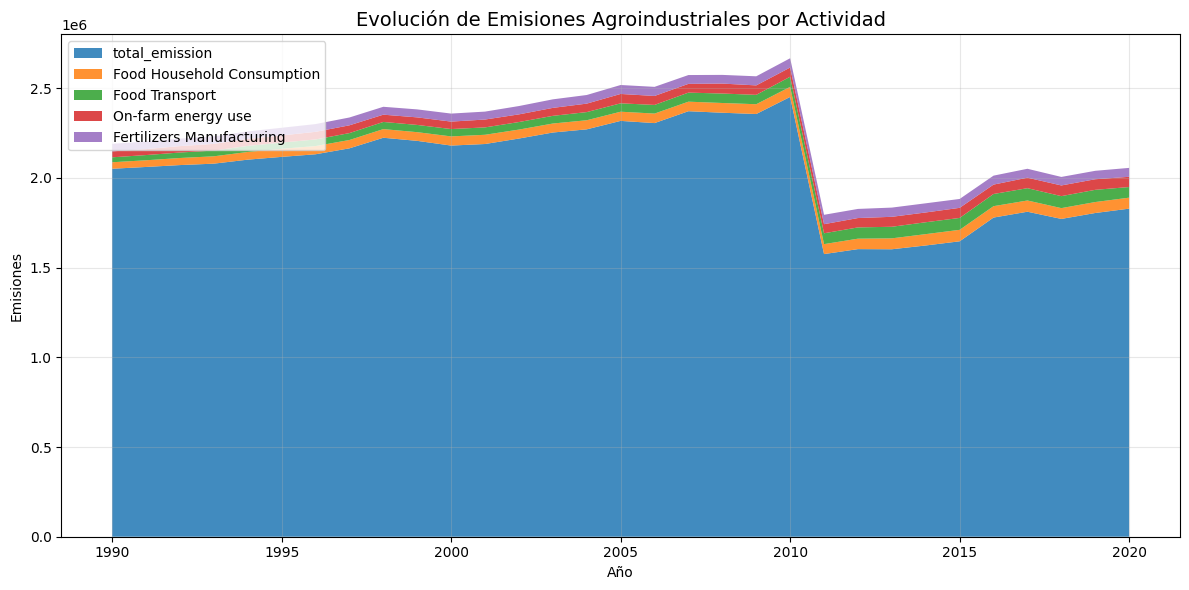

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 2. DETECTAR COLUMNA DE AÑO
# =========================
# Busca una columna tipo Year / Año / year
year_candidates = [c for c in df.columns if c.lower() in ["year", "año", "anio"]]

if not year_candidates:
    raise ValueError("No se encontró columna de año (Year / Año / anio).")

YEAR_COL = year_candidates[0]

# =========================
# 3. SELECCIONAR VARIABLES NUMÉRICAS
# =========================
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols.remove(YEAR_COL)

if len(numeric_cols) < 2:
    raise ValueError("No hay suficientes columnas numéricas para graficar.")

# =========================
# 4. ELEGIR LAS 5 MÁS IMPORTANTES
#    (mayor volumen total)
# =========================
top_cols = (
    df[numeric_cols]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Variables utilizadas en la gráfica:")
for c in top_cols:
    print("-", c)

# =========================
# 5. AGRUPAR POR AÑO (SUMA)
# =========================
df_year = (
    df.groupby(YEAR_COL)[top_cols]
      .sum()
      .sort_index()
)

# =========================
# 6. GRÁFICA DE ÁREA APILADA
# =========================
plt.figure(figsize=(12, 6))

plt.stackplot(
    df_year.index,
    df_year.T,
    labels=top_cols,
    alpha=0.85
)

plt.title("Evolución de Emisiones Agroindustriales por Actividad", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Emisiones")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


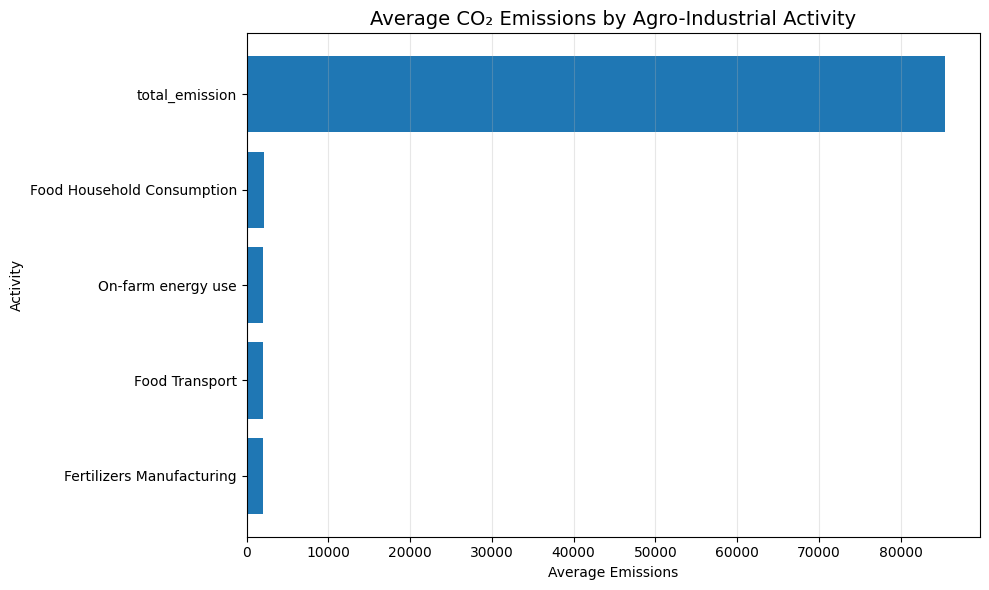

In [23]:
import matplotlib.pyplot as plt

# =========================
# 1. PROMEDIO ANUAL POR ACTIVIDAD
# =========================
avg_emissions = (
    df[top_cols]
    .mean()
    .sort_values(ascending=True)
)

# =========================
# 2. BAR CHART HORIZONTAL
# =========================
plt.figure(figsize=(10, 6))

plt.barh(
    avg_emissions.index,
    avg_emissions.values
)

plt.title("Average CO₂ Emissions by Agro-Industrial Activity", fontsize=14)
plt.xlabel("Average Emissions")
plt.ylabel("Activity")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


The chart shows the average contribution of each agro-industrial activity to total CO₂ emissions. A small number of activities account for most emissions, while the rest have a much lower impact.

This indicates that CO₂ emissions in the agro-food sector are highly concentrated. Targeting a few key activities could therefore lead to more effective emission reduction strategies.

Variables utilizadas en la gráfica:
- Food Household Consumption
- Food Transport
- On-farm energy use
- Fertilizers Manufacturing
- Food Retail


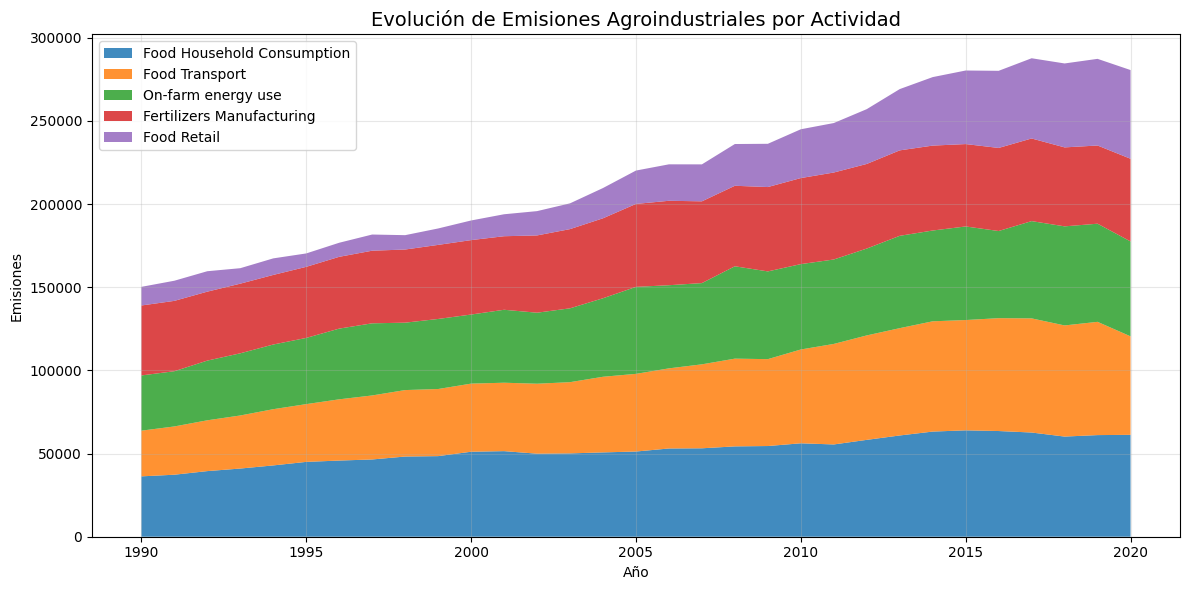

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 2. DETECTAR COLUMNA DE AÑO
# =========================
year_candidates = [c for c in df.columns if c.lower() in ["year", "año", "anio"]]

if not year_candidates:
    raise ValueError("No se encontró columna de año (Year / Año / anio).")

YEAR_COL = year_candidates[0]

# =========================
# 3. SELECCIONAR VARIABLES NUMÉRICAS
# =========================
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols.remove(YEAR_COL)

# ❌ EXCLUIR total_emission
numeric_cols = [
    c for c in numeric_cols
    if c.lower() != "total_emission"
]

if len(numeric_cols) < 2:
    raise ValueError("No hay suficientes columnas numéricas para graficar.")

# =========================
# 4. ELEGIR LAS 5 MÁS IMPORTANTES
# =========================
top_cols = (
    df[numeric_cols]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Variables utilizadas en la gráfica:")
for c in top_cols:
    print("-", c)

# =========================
# 5. AGRUPAR POR AÑO (SUMA)
# =========================
df_year = (
    df.groupby(YEAR_COL)[top_cols]
      .sum()
      .sort_index()
)

# =========================
# 6. GRÁFICA DE ÁREA APILADA
# =========================
plt.figure(figsize=(12, 6))

plt.stackplot(
    df_year.index,
    df_year.T,
    labels=top_cols,
    alpha=0.85
)

plt.title("Evolución de Emisiones Agroindustriales por Actividad", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Emisiones")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Variables utilizadas en la gráfica:
- Food Household Consumption
- Food Transport
- On-farm energy use
- Fertilizers Manufacturing
- Food Retail


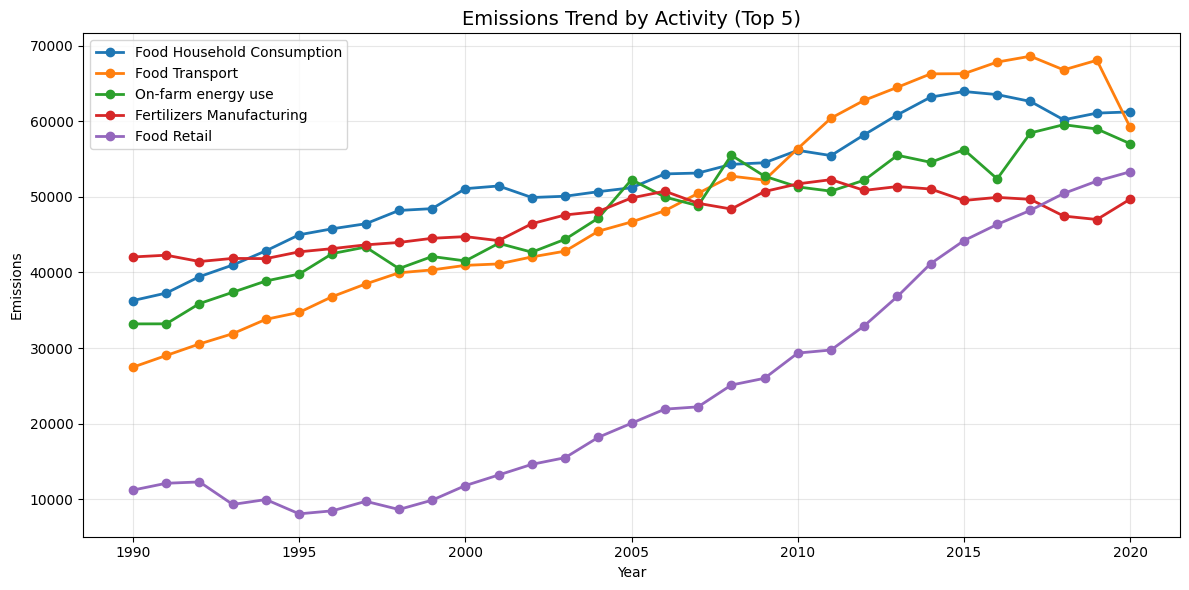

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. DETECTAR COLUMNA DE AÑO
# =========================
year_candidates = [c for c in df.columns if c.lower() in ["year", "año", "anio"]]
if not year_candidates:
    raise ValueError("No se encontró columna de año (Year / Año / anio).")
YEAR_COL = year_candidates[0]

# =========================
# 2. SELECCIONAR VARIABLES NUMÉRICAS (EXCLUYENDO total_emission)
# =========================
numeric_cols = df.select_dtypes(include="number").columns.tolist()
if YEAR_COL in numeric_cols:
    numeric_cols.remove(YEAR_COL)

numeric_cols = [c for c in numeric_cols if c.lower() != "total_emission"]

if len(numeric_cols) < 2:
    raise ValueError("No hay suficientes columnas numéricas para graficar.")

# =========================
# 3. TOP 5 ACTIVIDADES (mayor volumen total)
# =========================
top_cols = (
    df[numeric_cols]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Variables utilizadas en la gráfica:")
for c in top_cols:
    print("-", c)

# =========================
# 4. AGRUPAR POR AÑO (SUMA)
# =========================
df_year = (
    df.groupby(YEAR_COL)[top_cols]
      .sum()
      .sort_index()
)

# =========================
# 5. GRÁFICO DE LÍNEAS (no apilado)
# =========================
plt.figure(figsize=(12, 6))

for col in top_cols:
    plt.plot(df_year.index, df_year[col], marker='o', linewidth=2, label=col)

plt.title("Emissions Trend by Activity (Top 5)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Emissions")
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


This line chart shows how CO₂ emissions from the top five agro-industrial activities evolve over time. Each line represents a single activity, making it easier to compare trends across activities.

Some activities show a steady increase in emissions, while others remain stable or fluctuate. This indicates that emission growth is not uniform across the agro-food sector, and different activities follow different trajectories over time.

### **Univariate Analysis**

Outliers check

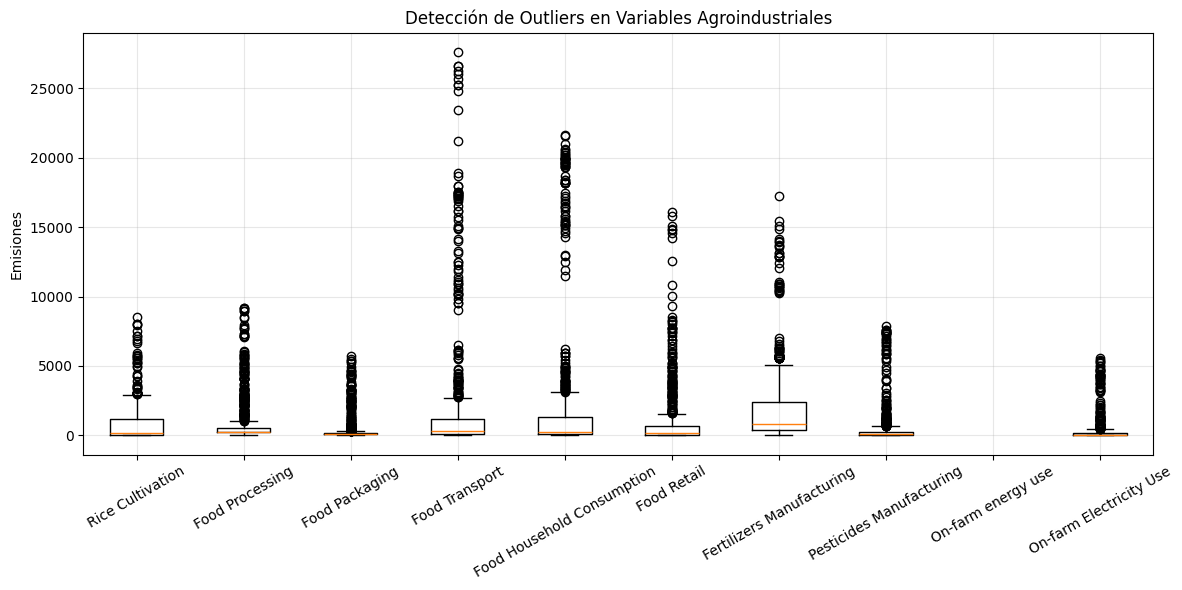

In [26]:
import matplotlib.pyplot as plt

cols = [
    "Rice Cultivation",
    "Food Processing",
    "Food Packaging",
    "Food Transport",
    "Food Household Consumption",
    "Food Retail",
    "Fertilizers Manufacturing",
    "Pesticides Manufacturing",
    "On-farm energy use",
    "On-farm Electricity Use"
]

plt.figure(figsize=(12,6))
plt.boxplot(
    [df[c] for c in cols],
    labels=cols,
    showfliers=True
)

plt.title("Detección de Outliers en Variables Agroindustriales")
plt.ylabel("Emisiones")
plt.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


The boxplot shows strong variability in CO₂ emissions across agro-industrial activities. Several activities contain clear outliers, indicating that a small number of observations drive very high emission values. This suggests that outliers may significantly affect the analysis and should be handled carefully.

Variables usadas para la distribución logarítmica:
- total_emission
- Food Household Consumption
- Food Transport
- On-farm energy use
- Fertilizers Manufacturing


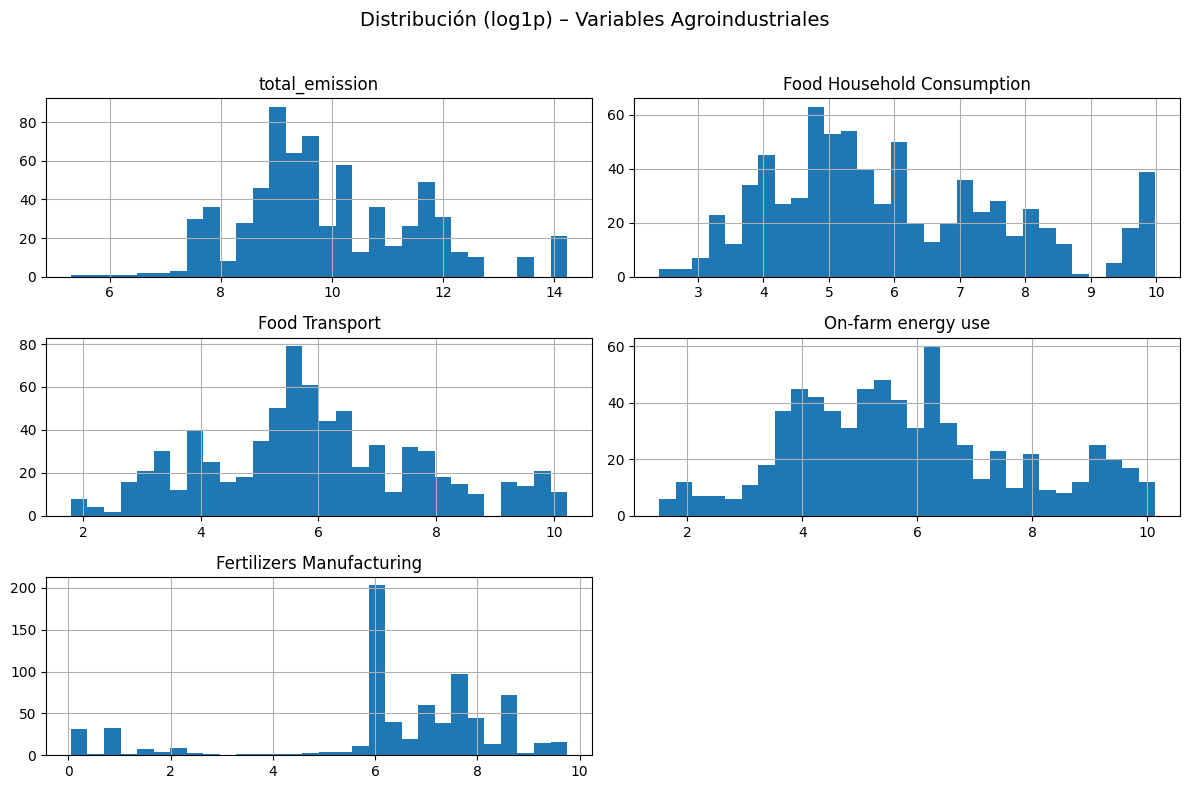

In [27]:
#Aplicamos la transformacion logaritmica para los casos que vimos anteriormente que tenian outliers.

#=========================
# 2. DETECTAR COLUMNA DE AÑO
# =========================
year_candidates = [c for c in df.columns if c.lower() in ["year", "año", "anio"]]

if not year_candidates:
    raise ValueError("No se encontró columna de año (Year / Año / anio).")

YEAR_COL = year_candidates[0]

# =========================
# 3. SELECCIONAR VARIABLES NUMÉRICAS
# =========================
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols.remove(YEAR_COL)

if len(numeric_cols) < 2:
    raise ValueError("No hay suficientes columnas numéricas para analizar.")

# =========================
# 4. ELEGIR LAS 5 MÁS RELEVANTES
#    (mayor volumen total)
# =========================
cols_emision = (
    df[numeric_cols]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Variables usadas para la distribución logarítmica:")
for c in cols_emision:
    print("-", c)

# =========================
# 5. TRANSFORMACIÓN LOG1P
# =========================
df_log = np.log1p(df[cols_emision])

# =========================
# 6. HISTOGRAMAS (LOG1P)
# =========================
df_log.hist(
    bins=30,
    figsize=(12, 8),
    layout=(3, 2)
)

plt.suptitle("Distribución (log1p) – Variables Agroindustriales", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()




Variables usadas para la distribución logarítmica:
- total_emission
- Food Household Consumption
- Food Transport
- On-farm energy use
- Fertilizers Manufacturing


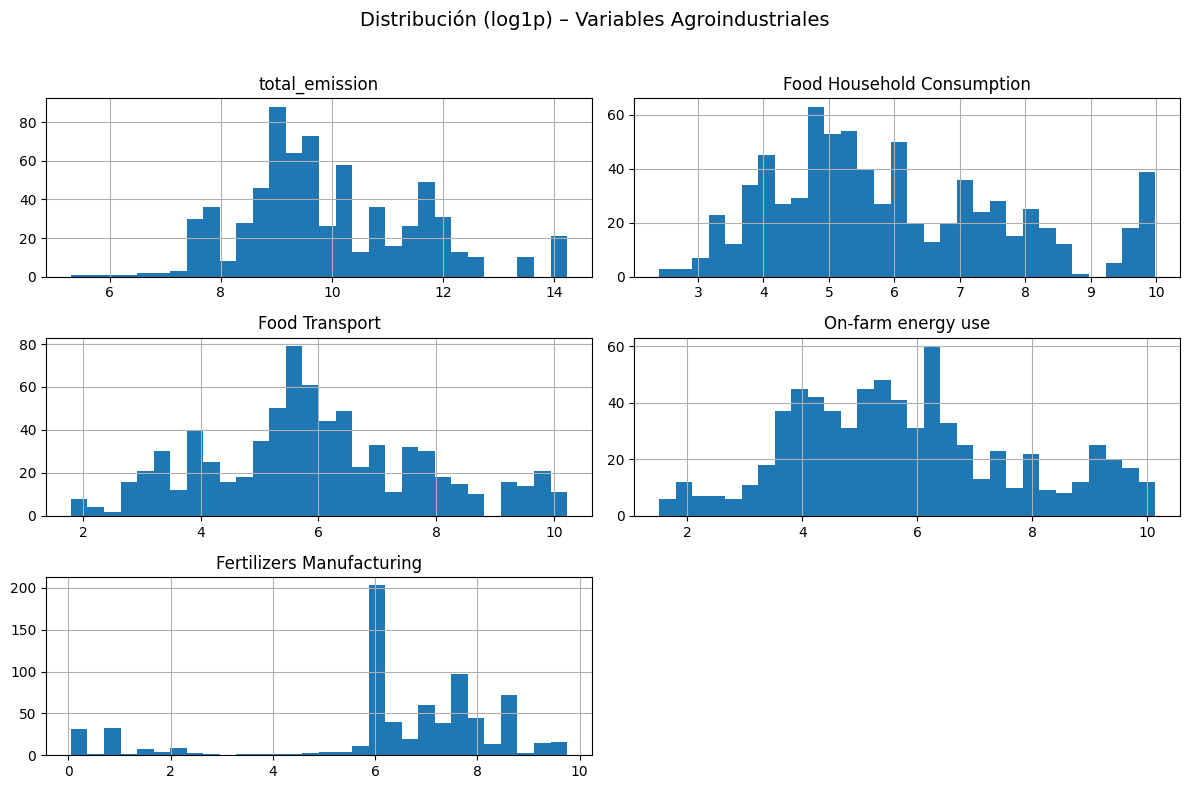

In [28]:
# =========================
# 2. DETECTAR COLUMNA DE AÑO
# =========================
year_candidates = df["Year"]

# YEAR_COL = year_candidates[0]

# =========================
# 3. SELECCIONAR VARIABLES NUMÉRICAS
# =========================
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols.remove(YEAR_COL)

if len(numeric_cols) < 2:
    raise ValueError("No hay suficientes columnas numéricas para analizar.")

# =========================
# 4. ELEGIR LAS 5 MÁS RELEVANTES
#    (mayor volumen total)
# =========================
cols_emision = (
    df[numeric_cols]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Variables usadas para la distribución logarítmica:")
for c in cols_emision:
    print("-", c)

# =========================
# 5. TRANSFORMACIÓN LOG1P
# =========================
df_log = np.log1p(df[cols_emision])

# =========================
# 6. HISTOGRAMAS (LOG1P)
# =========================
df_log.hist(
    bins=30,
    figsize=(12, 8),
    layout=(3, 2)
)

plt.suptitle("Distribución (log1p) – Variables Agroindustriales", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()




This code first detects the year column to ensure time-related variables are handled correctly. It then selects only numeric columns and keeps the five variables with the largest total emissions, focusing the analysis on the main contributors.

Next, it applies a log1p transformation to reduce skewness and make heavily right-skewed emission variables easier to visualize and compare. Finally, it plots histograms of the transformed variables, which helps assess distribution shape, variability, and potential outliers in a more readable scale.

In [29]:
import numpy as np

df_log = df.copy()
for c in cols:
    df_log[c] = np.log1p(df[c])


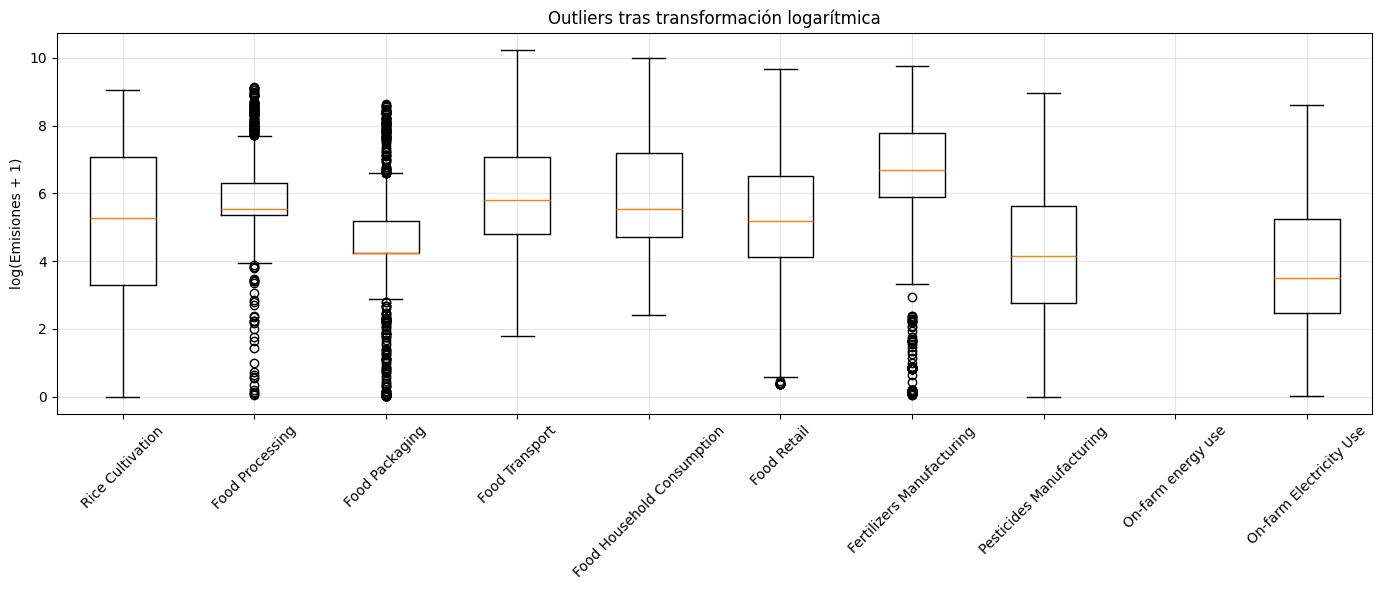

In [30]:
plt.figure(figsize=(14,6))
plt.boxplot(
    [df_log[c] for c in cols],
    labels=cols,
    showfliers=True
)
plt.title("Outliers tras transformación logarítmica")
plt.ylabel("log(Emisiones + 1)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


This boxplot shows the distribution of agro-industrial emissions after applying a logarithmic transformation. Compared to the original scale, extreme values are less pronounced, and the distributions appear more compact.

While some outliers remain, their influence is reduced, making the data more suitable for comparison and modeling. This confirms that the log transformation helps stabilize variance and improves interpretability.

The log transformation reduces skewness and limits the impact of extreme values. This results in more stable distributions, making the variables more suitable for comparison and modeling.

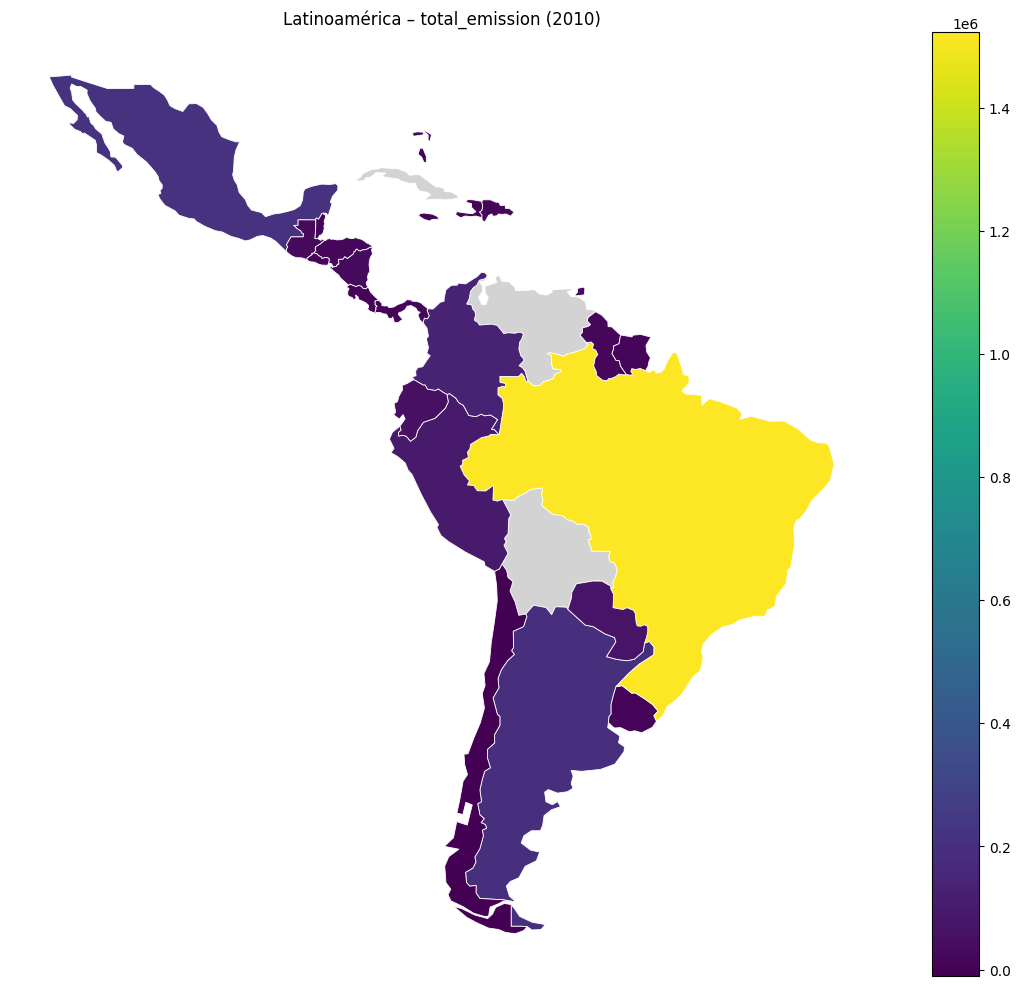

Países sin datos:
         NAME
8     Bolivia
18  Venezuela
23       Cuba


In [31]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# ========= CONFIG =========
YEAR = 2010
VAR = "total_emission"
# ==========================

# --- 1) Filtrar año ---
df_y = df[df["Year"] == YEAR].copy()
df_y = df_y.groupby("Area", as_index=False)[VAR].sum()

# --- 2) Cargar mapa mundial (Natural Earth 110m) ---
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# --- 3) Filtrar Latinoamérica ---
LATAM_NAMES = {
    "Mexico","Guatemala","Belize","Honduras","El Salvador","Nicaragua","Costa Rica","Panama",
    "Cuba","Haiti","Dominican Rep.","Jamaica","Trinidad and Tobago","Bahamas",
    "Colombia","Venezuela","Guyana","Suriname","Ecuador","Peru","Bolivia","Brazil",
    "Paraguay","Uruguay","Argentina","Chile"
}

latam = world[world["NAME"].isin(LATAM_NAMES)].copy()

# --- 4) Ajustar nombres para merge ---
name_fix = {
    "Dominican Rep.": "Dominican Republic",
    "Venezuela": "Venezuela",
    "Bolivia": "Bolivia",
    "Brazil": "Brazil"
}

latam["Area"] = latam["NAME"].replace(name_fix)

# --- 5) Merge ---
gdf = latam.merge(df_y, on="Area", how="left")

# --- 6) Plot ---
fig, ax = plt.subplots(figsize=(12,10))

latam.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)
gdf.dropna(subset=[VAR]).plot(
    ax=ax,
    column=VAR,
    legend=True,
    edgecolor="white",
    linewidth=0.6
)

ax.set_title(f"Latinoamérica – {VAR} ({YEAR})")
ax.axis("off")
plt.tight_layout()
plt.show()

# --- 7) Diagnóstico ---
print("Países sin datos:")
print(gdf[gdf[VAR].isna()][["NAME"]])


This map shows the spatial distribution of total CO₂ emissions across Latin American countries in 2010. Emissions are unevenly distributed, with a small number of countries concentrating the highest values.

The visualization highlights clear regional differences, suggesting that emission levels are driven by country-specific factors such as scale of production and economic activity. Countries without color indicate missing data rather than zero emissions.

Overall, the map helps identify geographic hotspots and supports a region-focused analysis of agro-food emissions.

### **Bivariate Analysis**

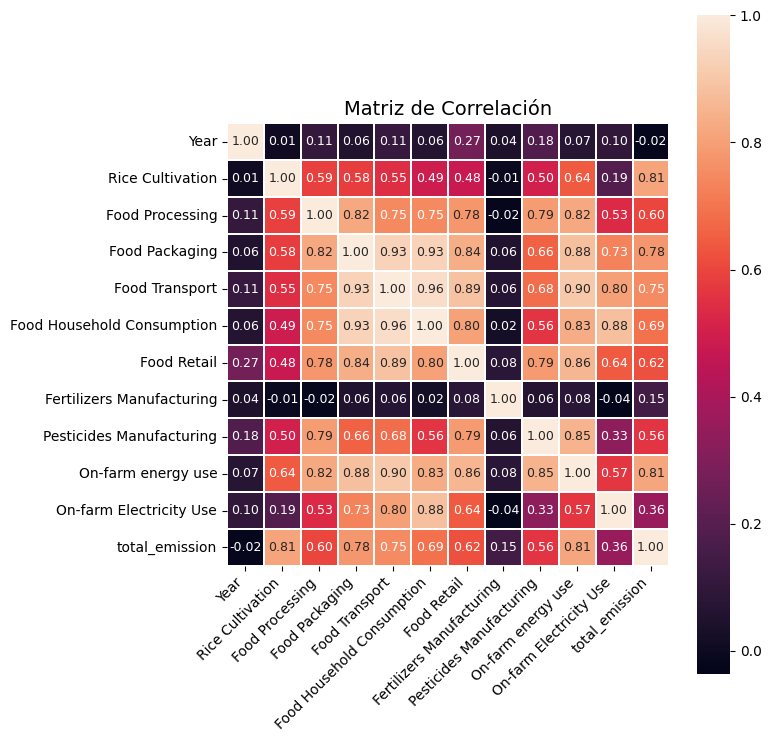

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. SELECCIONAR SOLO COLUMNAS NUMÉRICAS
# =========================
df_numeric = df.select_dtypes(include="number")

# =========================
# 2. MATRIZ DE CORRELACIÓN
# =========================
corr_matrix = df_numeric.corr()

# =========================
# 3. CONFIGURACIÓN VISUAL
# =========================
plt.figure(figsize=(8, 8))

sns.heatmap(
    corr_matrix,
    annot=True,          # mostrar valores
    fmt=".2f",           # 2 decimales
    cmap="rocket",       # similar al ejemplo
    linewidths=0.3,
    square=True,
    cbar=True,
    annot_kws={"size": 9}
)

plt.title("Matriz de Correlación", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


**Key Highlights from the Correlation Matrix**

1-Food Processing, Packaging, Transport, Household Consumption, and Retail show strong positive correlations with each other, indicating closely linked emission sources within the food supply chain.

2-On-farm energy use has a strong correlation with total emissions, making it a key driver of overall CO₂ levels.

3-Rice cultivation is also strongly correlated with total emissions, highlighting its significant contribution.

4-Fertilizers and Pesticides Manufacturing show weak correlations with most variables, suggesting a more independent emission pattern.

5-Year has very low correlation with emissions, indicating that changes over time are driven more by activity levels than by a simple time trend.

In addition to the correlation matrix, scatter plots were used to visually assess relationships between total emissions and key drivers. Log-transformed plots reveal clearer patterns and reduce the influence of extreme values.

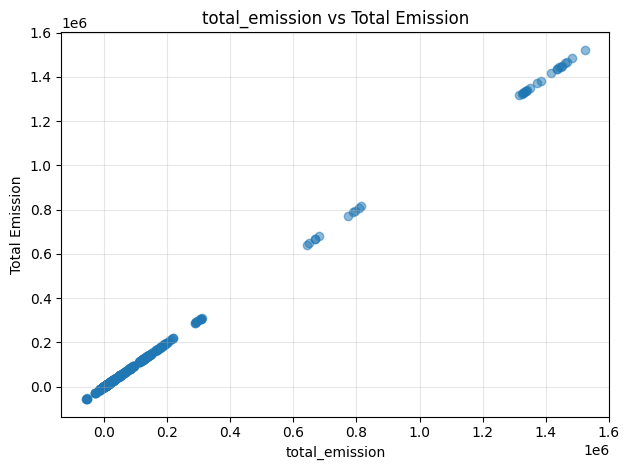

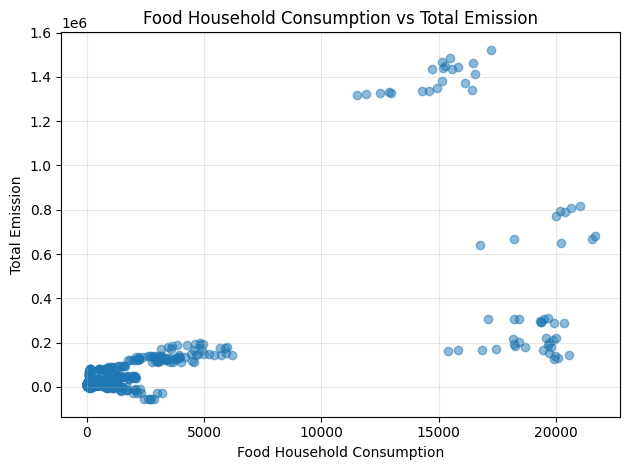

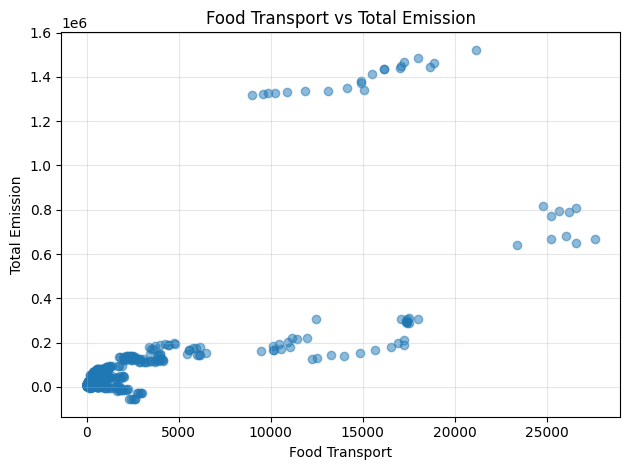

In [33]:
import matplotlib.pyplot as plt

drivers = cols_emision[:3]  # top 3 drivers

for col in drivers:
    plt.figure()
    plt.scatter(df[col], df["total_emission"], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel("Total Emission")
    plt.title(f"{col} vs Total Emission")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


This scatter plot shows the relationship between total CO₂ emissions and key agro-industrial drivers. A positive association is visible, although the relationship is not strictly linear. The wide dispersion of points highlights high variability and the presence of extreme values.

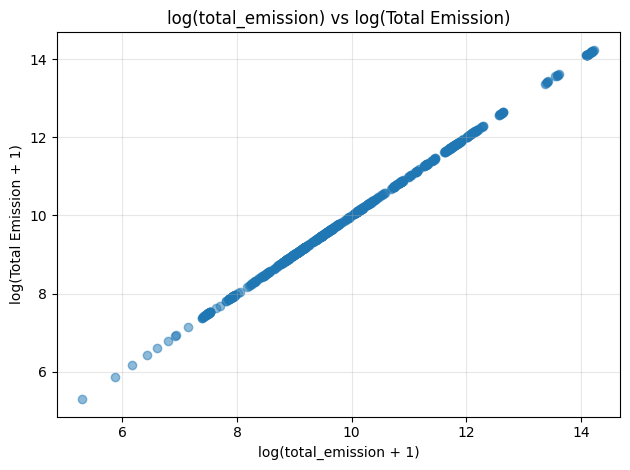

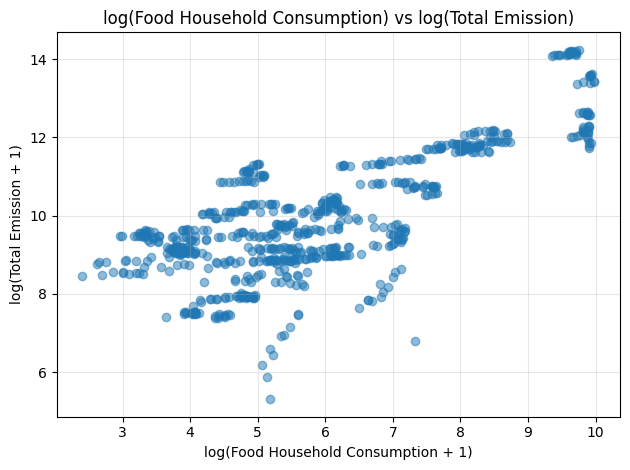

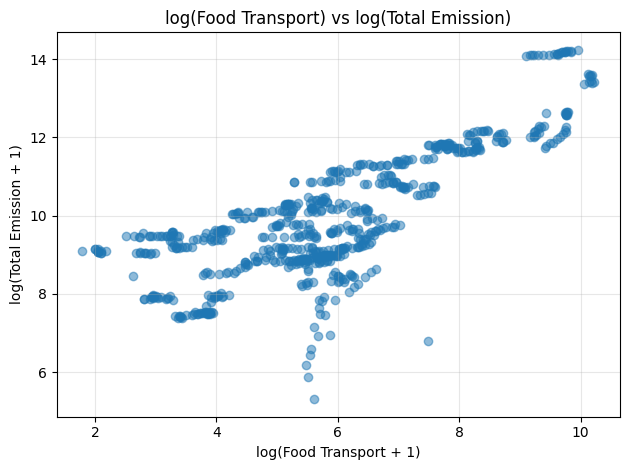

In [34]:
import numpy as np

for col in drivers:
    plt.figure()
    plt.scatter(np.log1p(df[col]), np.log1p(df["total_emission"]), alpha=0.5)
    plt.xlabel(f"log({col} + 1)")
    plt.ylabel("log(Total Emission + 1)")
    plt.title(f"log({col}) vs log(Total Emission)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


After applying a logarithmic transformation, the relationship between variables becomes clearer and more linear. The log scale reduces the influence of extreme values and reveals underlying patterns that are less visible in the original scale. This suggests that the log-transformed variables are more suitable for modeling.

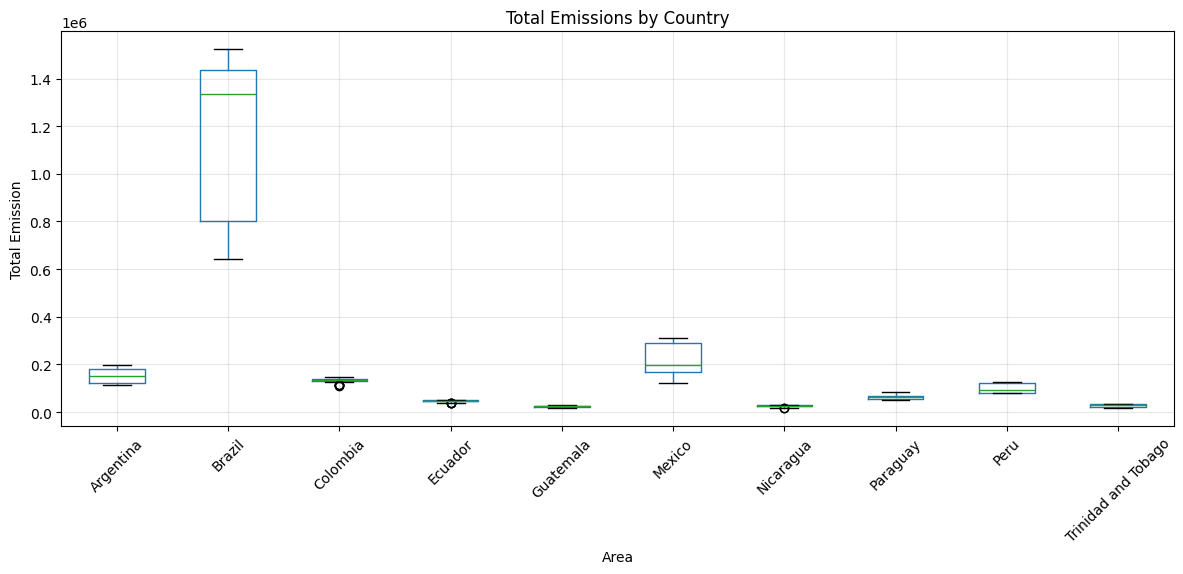

In [35]:
top_countries = df.groupby("Area")["total_emission"].sum().nlargest(10).index

df[df["Area"].isin(top_countries)].boxplot(
    column="total_emission",
    by="Area",
    figsize=(12,6)
)

plt.title("Total Emissions by Country")
plt.suptitle("")
plt.ylabel("Total Emission")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


This boxplot compares the distribution of total CO₂ emissions across countries. Emission levels vary significantly between countries, showing strong heterogeneity. A small number of countries exhibit very high emission values, indicating that total emissions are highly concentrated.

In [41]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# =========================
# CONFIGURACIÓN
# =========================
TOP_N_PANEL = 10
OUTPUT_HTML = "categorias_bid.html"  # ← nombre del archivo

# ⛔ Excluir explícitamente total_emission
activity_cols = [
    c for c in df.columns
    if c not in ["Area", "Year", "total_emission"]
]

# =========================
# TRANSFORMACIÓN DE DATOS
# =========================
df_long = df.melt(
    id_vars=["Area", "Year"],
    value_vars=activity_cols,
    var_name="Categoria",
    value_name="Emision"
)

df_cat_year = (
    df_long
    .groupby(["Year", "Categoria"], as_index=False)["Emision"]
    .sum()
)

total_year = (
    df_cat_year
    .groupby("Year", as_index=False)["Emision"]
    .sum()
    .rename(columns={"Emision": "Total_Anual"})
)

df_cat_year = df_cat_year.merge(total_year, on="Year")
df_cat_year["Participacion_%"] = (
    df_cat_year["Emision"] / df_cat_year["Total_Anual"] * 100
)

years = sorted(df_cat_year["Year"].dropna().unique())

# =========================
# MAPA DE COLORES (FIJO)
# =========================
palette = [
    "#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A",
    "#19D3F3", "#FF6692", "#B6E880", "#FF97FF", "#FECB52"
]

categorias = sorted(df_cat_year["Categoria"].unique())
color_map = {
    cat: palette[i % len(palette)]
    for i, cat in enumerate(categorias)
}

# =========================
# FUNCIÓN PARA CADA FRAME
# =========================
def build_frame(year):
    d = df_cat_year[df_cat_year["Year"] == year].copy()

    d_bar = (
        d.sort_values("Emision", ascending=False)
        .head(TOP_N_PANEL)
        .sort_values("Emision")
    )

    scatter = go.Scatter(
        x=d["Emision"],
        y=d["Participacion_%"],
        mode="markers+text",
        text=d["Categoria"],
        textposition="top center",
        marker=dict(
            size=(d["Emision"] / d["Emision"].max() * 50).fillna(10),
            color=d["Categoria"].map(color_map)
        ),
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Emisión: %{x:,.0f}<br>"
            "Participación: %{y:.2f}%<extra></extra>"
        ),
        showlegend=False
    )

    bars = go.Bar(
        x=d_bar["Emision"],
        y=d_bar["Categoria"],
        orientation="h",
        marker=dict(color=d_bar["Categoria"].map(color_map)),
        hovertemplate="<b>%{y}</b><br>Emisión: %{x:,.0f}<extra></extra>",
        showlegend=False
    )

    return scatter, bars

# =========================
# FIGURA PRINCIPAL
# =========================
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.6, 0.4],
    subplot_titles=(
        "Emisiones vs participación (%) por categoría",
        f"Top {TOP_N_PANEL} categorías"
    )
)

s0, b0 = build_frame(years[0])
fig.add_trace(s0, row=1, col=1)
fig.add_trace(b0, row=1, col=2)

fig.frames = [
    go.Frame(name=str(int(y)), data=build_frame(y))
    for y in years
]

fig.update_layout(
    template="plotly_white",
    title="BID – Panel ejecutivo de emisiones agroindustriales por categoría",
    xaxis_title="Emisiones (kt)",
    yaxis_title="Participación (%)",
    xaxis2_title="Emisiones (kt)",
    margin=dict(l=40, r=40, t=90, b=60),
    updatemenus=[dict(
        type="buttons",
        showactive=False,
        x=0.08, y=-0.12,
        buttons=[
            dict(
                label="▶ Play",
                method="animate",
                args=[None, {
                    "frame": {"duration": 600, "redraw": True},
                    "fromcurrent": True
                }]
            ),
            dict(
                label="⏸ Pause",
                method="animate",
                args=[[None], {
                    "frame": {"duration": 0},
                    "mode": "immediate"
                }]
            )
        ]
    )],
    sliders=[dict(
        x=0.12, y=-0.12,
        steps=[
            dict(
                method="animate",
                args=[[str(int(y))], {
                    "mode": "immediate",
                    "frame": {"duration": 0, "redraw": True}
                }],
                label=str(int(y))
            )
            for y in years
        ]
    )]
)

# =========================
# 💾 GUARDAR A HTML
# =========================
fig.write_html(
    OUTPUT_HTML,
    include_plotlyjs="cdn",
    full_html=True
)

print(f"Archivo generado correctamente: {OUTPUT_HTML}")
print("Abrilo con doble clic o desde el navegador.")


Archivo generado correctamente: categorias_bid.html
Abrilo con doble clic o desde el navegador.
